# **Learn All Kind Of Plots Using Seaborn**

---

## What You Will Learn in This Notebook

This notebook is a **complete reference guide** for visualizing data with **Seaborn**.

By the end, you will know:
- **What plots exist in Seaborn**
- **When to use each plot**
- **Two syntax styles for every plot (Figure-level and Axes-level)**

---

### Table of Contents

| # | Category | Plots Covered |
|---|----------|---------------|
| 1 | Relational Plots | Scatter Plot, Line Plot |
| 2 | Distribution Plots | Histogram, KDE Plot, Rug Plot |
| 3 | Categorical Plots | Bar Plot, Count Plot, Box Plot, Violin Plot, Swarm Plot |
| 4 | Matrix Plots | Heatmap, Clustermap |
| 5 | Regression Plots | Regression Plot (regplot / lmplot) |

---

### Key Concept: Figure-Level vs Axes-Level Functions

This is the **most important idea** to understand before diving in.
Every plot in Seaborn can be made in **two ways**:

| | **Figure-Level Function** | **Axes-Level Function** |
|-|--------------------------|-------------------------|
| What it does | Manages the entire figure | Draws on one axes (subplot) |
| Returns | A FacetGrid object | A matplotlib Axes object |
| Multi-plot / Faceting | YES , via `col=` and `row=` | NO , single plot only |
| How to select plot type | Pass `kind=` parameter | Use the specific function directly |
| Examples | `sns.relplot()`, `sns.displot()`, `sns.catplot()` | `sns.scatterplot()`, `sns.histplot()`, `sns.boxplot()` |

**In short:**
- Use **Axes-level** when you want a quick single plot embedded in your own matplotlib figure.
- Use **Figure-level** when you want Seaborn to manage the layout , especially for faceting (splitting plots by category).

---

Official Seaborn API: https://seaborn.pydata.org/api.html

## **Setup , Import Libraries & Load Datasets**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Built-in Seaborn datasets
tips    = sns.load_dataset('tips')     # Restaurant tips data
iris    = sns.load_dataset('iris')     # Iris flower measurements
titanic = sns.load_dataset('titanic') # Titanic passenger data

# Plotly dataset
gap = px.data.gapminder()             # World economic / population data over years

print('All datasets loaded!')
tips.head(3)

All datasets loaded!


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


---

## **1. Relational Plots**

### What are Relational Plots?
Relational plots are used to **visualize the statistical relationship between two or more numerical variables** (Bivariate Analysis).

**When to use?**
- To check if two variables are correlated
- To spot trends, clusters, or outliers between variables

**Plots in this category:** Scatter Plot, Line Plot

- **Figure-level function:** `sns.relplot(kind="scatter"` or `"line")`
- **Axes-level functions:** `sns.scatterplot()` / `sns.lineplot()`

---

### **1.1 Scatter Plot**

**What is it?** Places a **dot for every data point** at position (x, y).

**Use it when:**
- You want to see the **relationship or correlation** between two continuous variables
- You want to **detect clusters or outliers**
- You want to encode extra info using `hue` (color), `style` (shape), or `size`

**Example:** Does total bill amount affect how much tip is given?

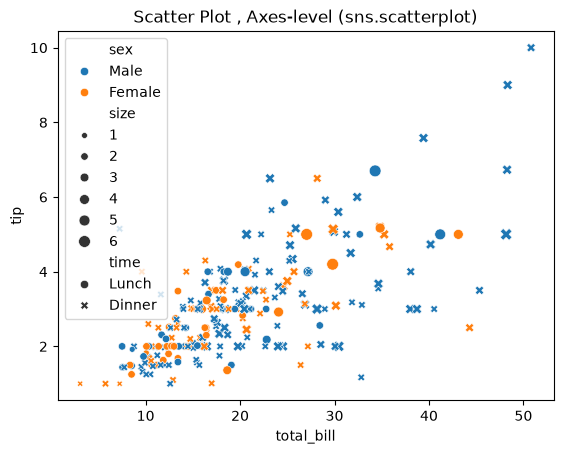

In [2]:
# AXES-LEVEL: sns.scatterplot()
# Draws directly on a matplotlib Axes , use for a single plot

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='sex',      # color by gender
    style='time',   # marker shape by time of day
    size='size'     # dot size by party size
)
plt.title('Scatter Plot , Axes-level (sns.scatterplot)')
plt.show()

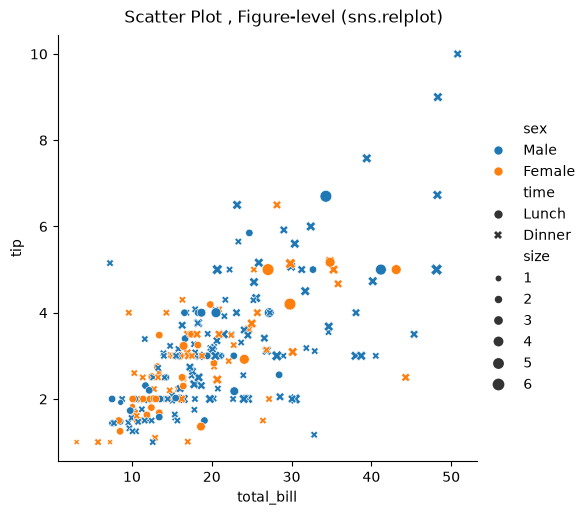

In [3]:
# FIGURE-LEVEL: sns.relplot(kind="scatter")
# Creates and manages its own figure , supports col= row= faceting

sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    kind='scatter',
    hue='sex',
    style='time',
    size='size'
)
plt.suptitle('Scatter Plot , Figure-level (sns.relplot)', y=1.02)
plt.show()

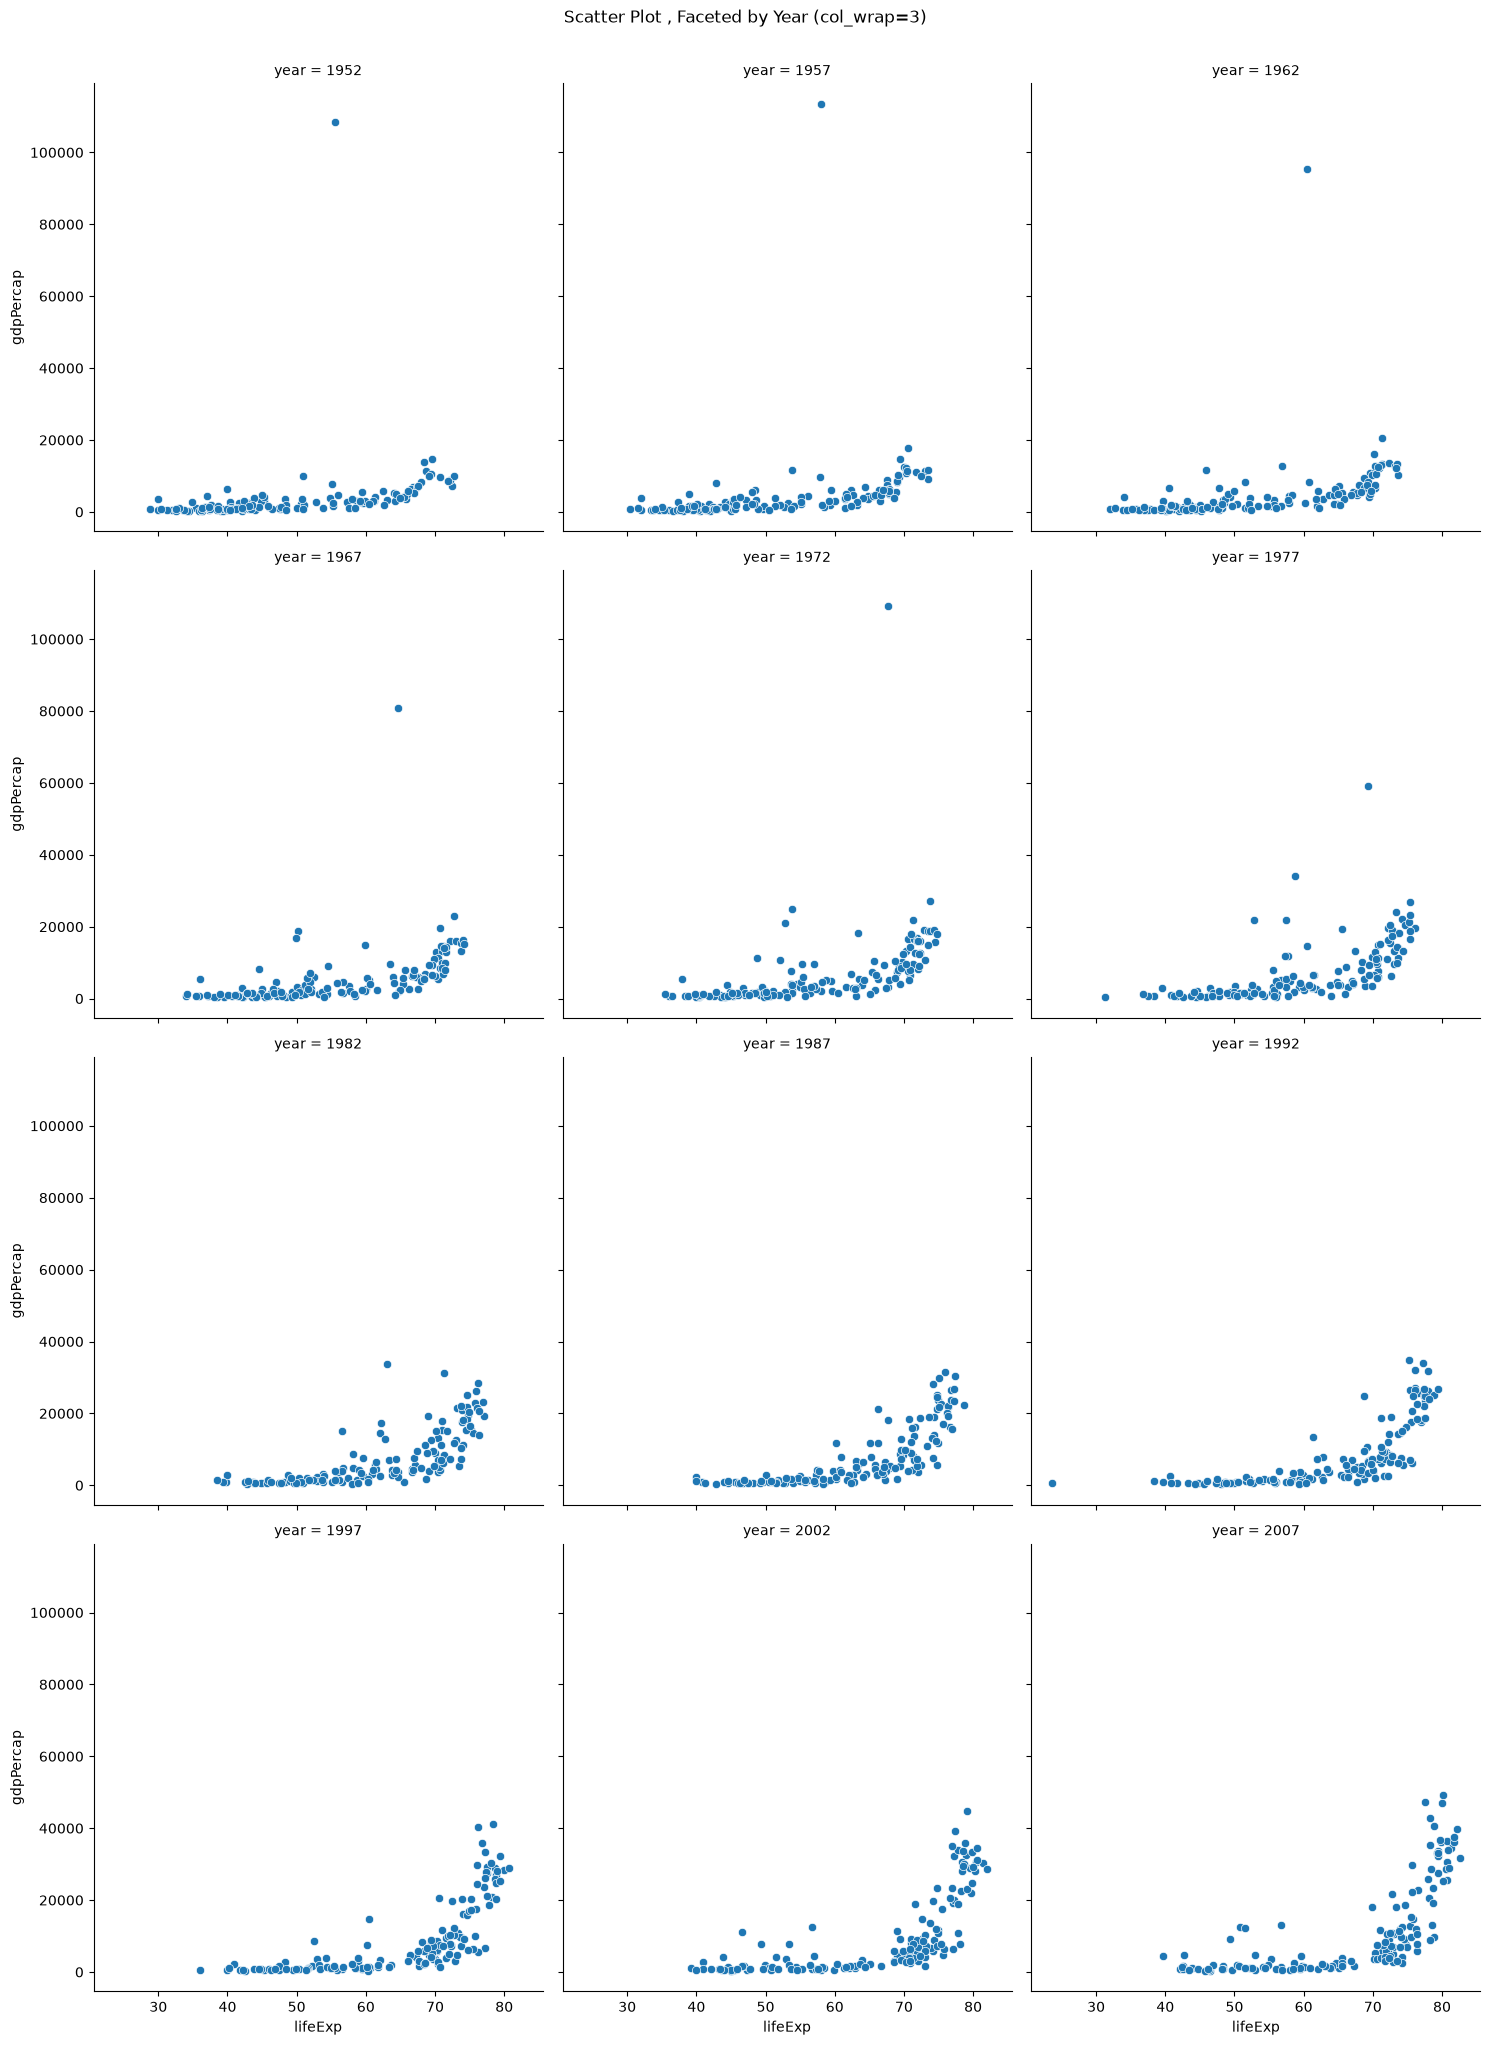

In [4]:
# FACETING , only possible with Figure-level relplot
# Split into panels by col= with col_wrap= to control layout

sns.relplot(
    data=gap,
    x='lifeExp',
    y='gdpPercap',
    kind='scatter',
    col='year',     # one column panel per year
    col_wrap=3      # wrap after 3 columns
)
plt.suptitle('Scatter Plot , Faceted by Year (col_wrap=3)', y=1.02)
plt.show()

### **1.2 Line Plot**

**What is it?** Connects data points with a **line**, showing change over a continuous axis.

**Use it when:**
- You have **time-series** or any ordered / sequential data
- You want to show **trends over time**
- You want to compare trends for **multiple groups**

**Example:** How has life expectancy changed over years for different countries?

In [5]:
# Prepare data: single country
temp_df = gap[gap['country'] == 'Pakistan']
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1164,Pakistan,Asia,1952,43.436,41346560,684.597144,PAK,586
1165,Pakistan,Asia,1957,45.557,46679944,747.083529,PAK,586
1166,Pakistan,Asia,1962,47.670,53100671,803.342742,PAK,586
1167,Pakistan,Asia,1967,49.800,60641899,942.408259,PAK,586
1168,Pakistan,Asia,1972,51.929,69325921,1049.938981,PAK,586


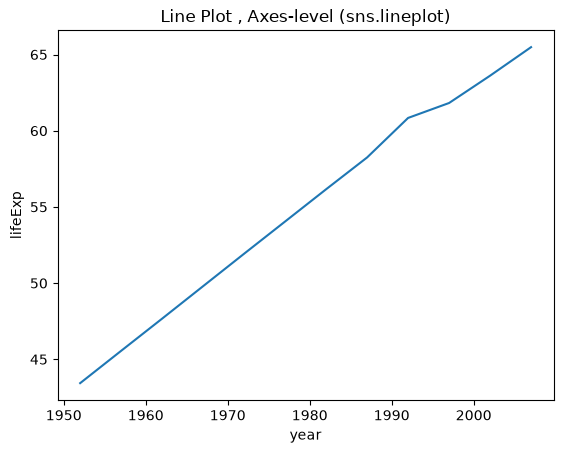

In [6]:
# AXES-LEVEL: sns.lineplot()
sns.lineplot(data=temp_df, x='year', y='lifeExp')
plt.title('Line Plot , Axes-level (sns.lineplot)')
plt.show()

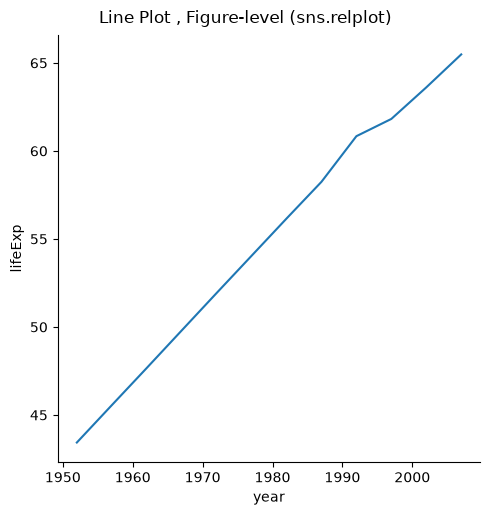

In [7]:
# FIGURE-LEVEL: sns.relplot(kind="line")
sns.relplot(data=temp_df, x='year', y='lifeExp', kind='line')
plt.suptitle('Line Plot , Figure-level (sns.relplot)', y=1.02)
plt.show()

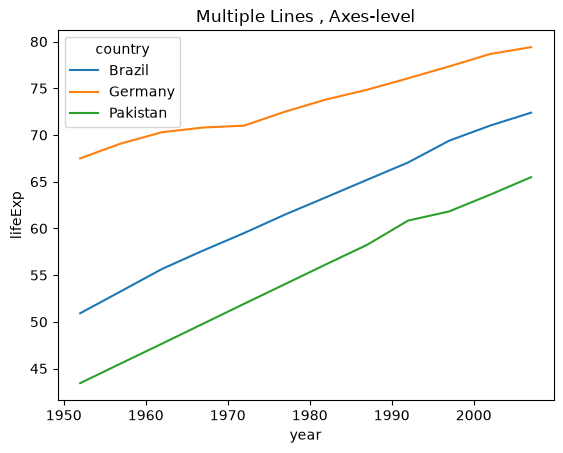

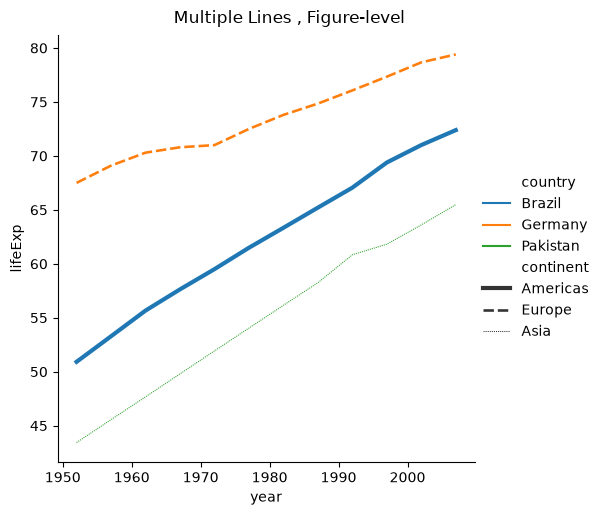

In [8]:
# MULTIPLE LINES , comparing countries
temp_df = gap[gap['country'].isin(['Pakistan', 'Brazil', 'Germany'])]

# Axes-level
sns.lineplot(data=temp_df, x='year', y='lifeExp', hue='country')
plt.title('Multiple Lines , Axes-level')
plt.show()

# Figure-level with style and size semantics
sns.relplot(
    kind='line', data=temp_df,
    x='year', y='lifeExp',
    hue='country', style='continent', size='continent'
)
plt.suptitle('Multiple Lines , Figure-level', y=1.02)
plt.show()

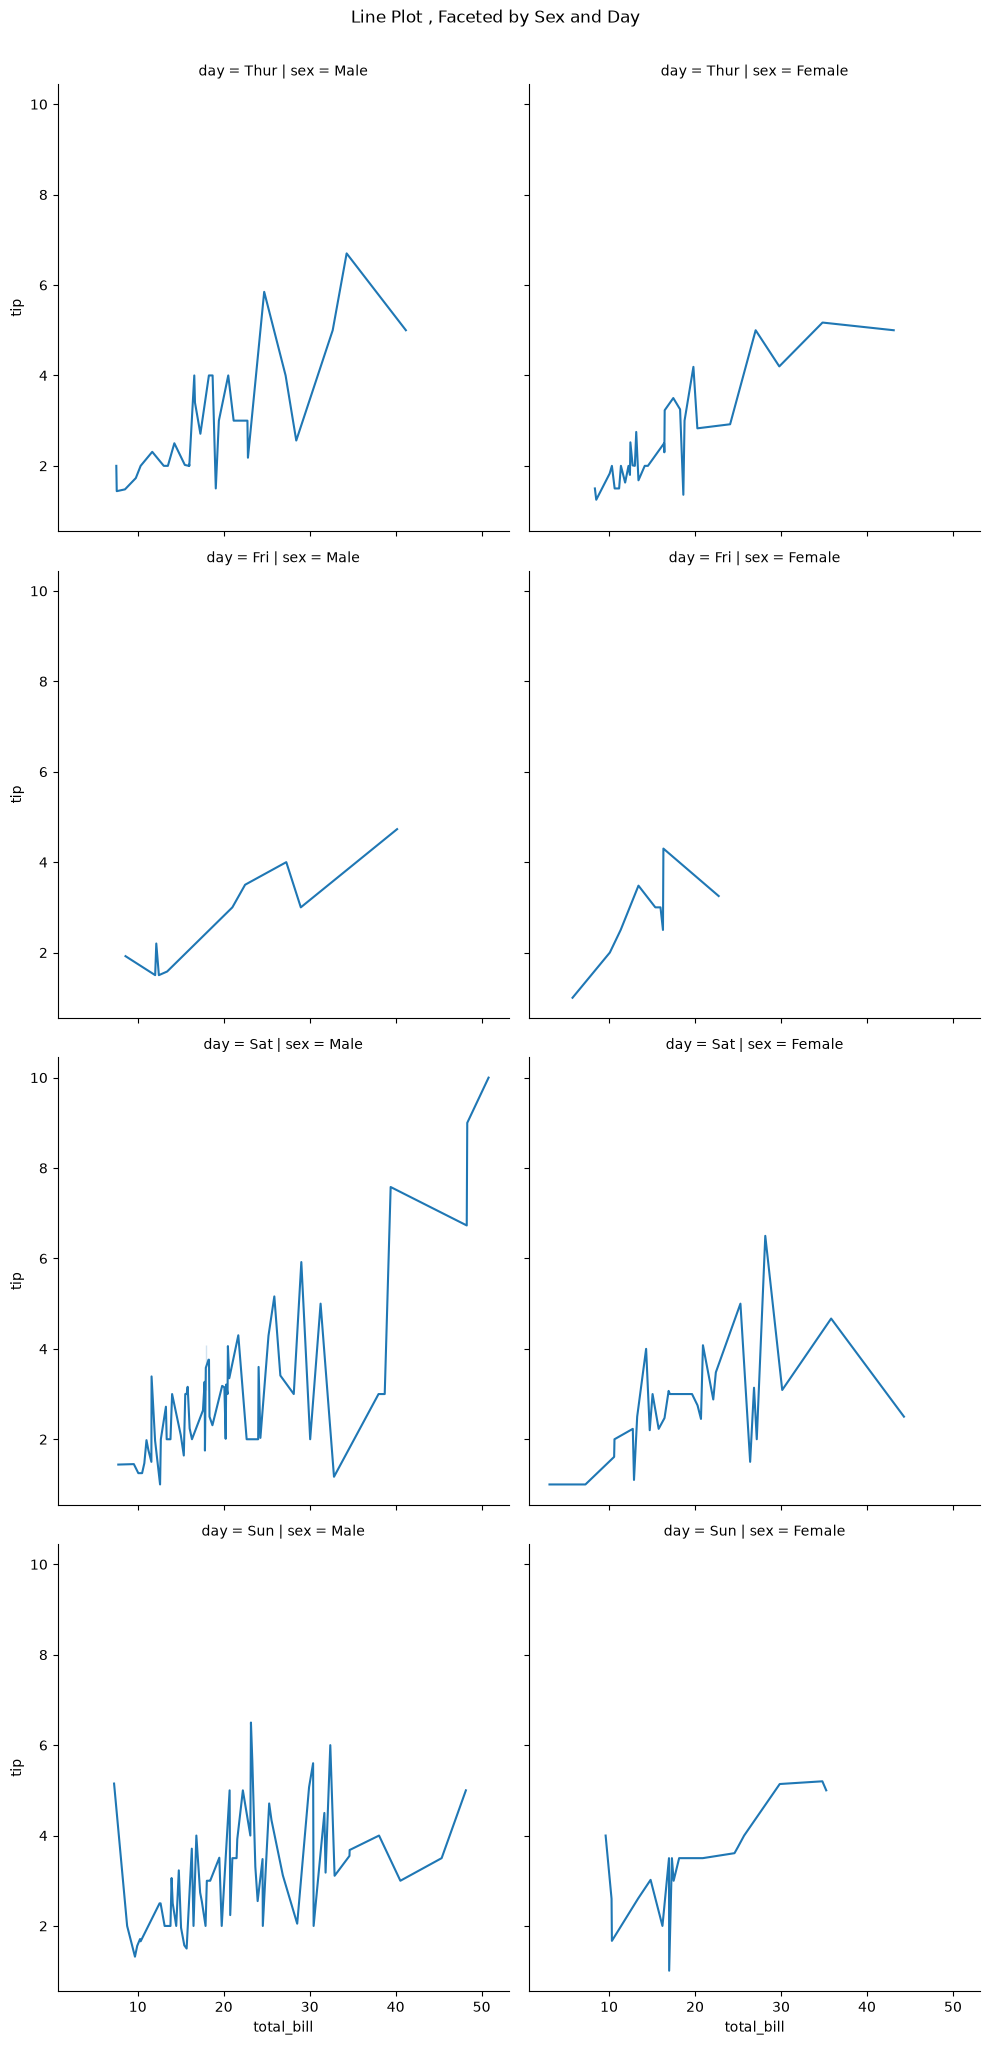

In [9]:
# FACETING with Line Plot , col= and row= only work with relplot
sns.relplot(
    data=tips,
    x='total_bill', y='tip',
    kind='line',
    col='sex',
    row='day'
)
plt.suptitle('Line Plot , Faceted by Sex and Day', y=1.02)
plt.show()

---

## **2. Distribution Plots**

### What are Distribution Plots?
Distribution plots are used to **understand how a single variable's values are spread** (Univariate Analysis).

**They help answer:**
- What is the **range** of observations?
- Where is the **center** (mean / median)?
- Is the data **symmetric or skewed**?
- Is the distribution **unimodal or bimodal** (one peak or two)?
- Are there **outliers**?

**Plots in this category:** Histogram, KDE Plot, Rug Plot

- **Figure-level function:** `sns.displot(kind="hist"` / `"kde")`
- **Axes-level functions:** `sns.histplot()` / `sns.kdeplot()` / `sns.rugplot()`

---

### **2.1 Histogram**

**What is it?** **Divides data into bins** (buckets) and counts observations per bin.
Shows the **frequency distribution** of a variable.

**Use it when:**
- You want to see the **shape of a distribution** (normal, skewed, bimodal)
- You want to **quickly summarize** how values are spread across a range
- You want to compare distributions of **two groups side-by-side**

**Key parameter:** `bins=` controls the number of buckets
(fewer bins = rougher picture, more bins = finer detail)

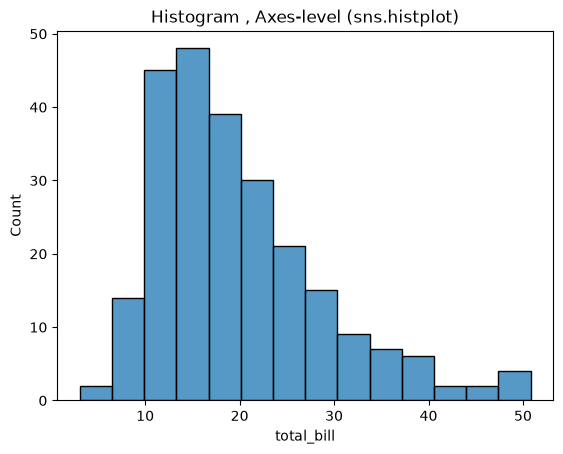

In [10]:
# AXES-LEVEL: sns.histplot()
sns.histplot(data=tips, x='total_bill')
plt.title('Histogram , Axes-level (sns.histplot)')
plt.show()

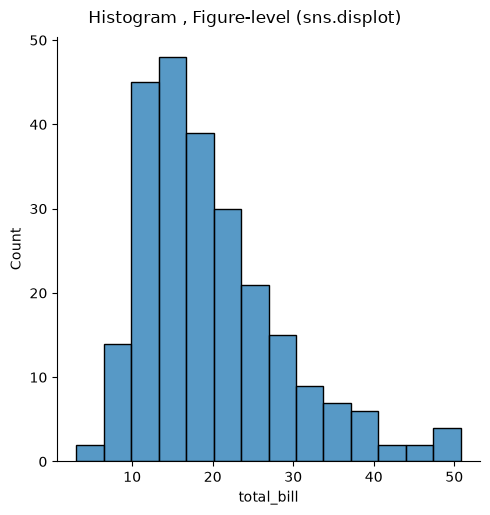

In [11]:
# FIGURE-LEVEL: sns.displot(kind="hist")
sns.displot(data=tips, x='total_bill', kind='hist')
plt.suptitle('Histogram , Figure-level (sns.displot)', y=1.02)
plt.show()

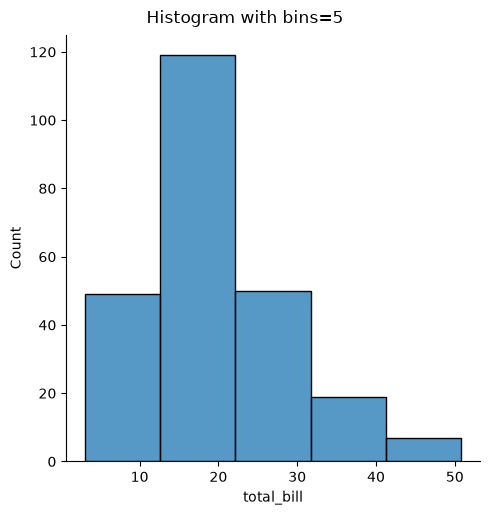

In [12]:
# bins= parameter , fewer bins = broader bars (less detail)
sns.displot(data=tips, x='total_bill', kind='hist', bins=5)
plt.suptitle('Histogram with bins=5', y=1.02)
plt.show()

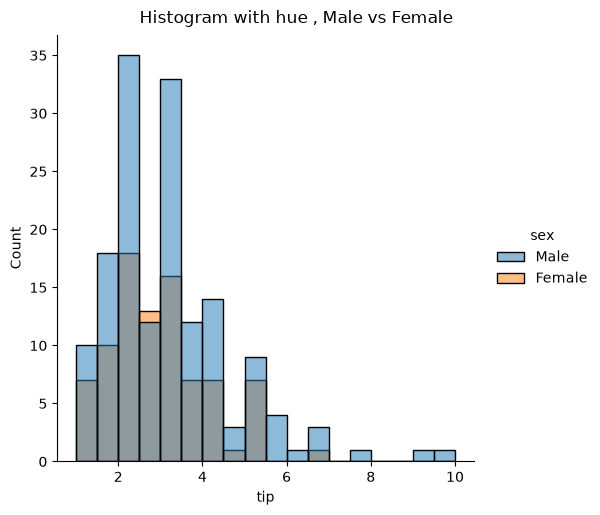

In [13]:
# hue= , compare two groups in one plot
sns.displot(data=tips, x='tip', kind='hist', hue='sex')
plt.suptitle('Histogram with hue , Male vs Female', y=1.02)
plt.show()

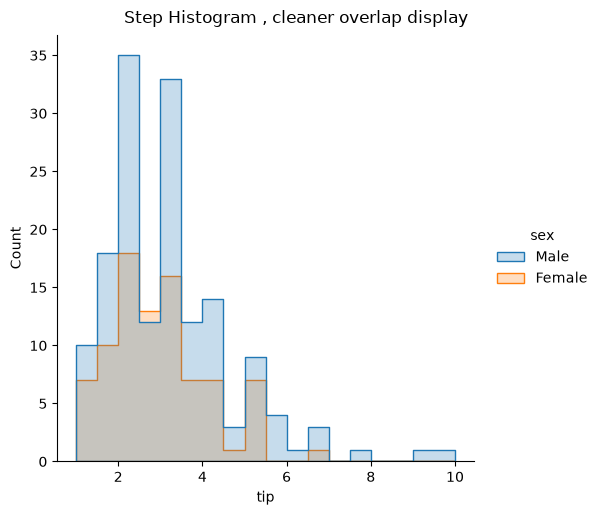

In [14]:
# element="step" , step-style histogram, cleaner for overlapping groups
sns.displot(data=tips, x='tip', kind='hist', hue='sex', element='step')
plt.suptitle('Step Histogram , cleaner overlap display', y=1.02)
plt.show()

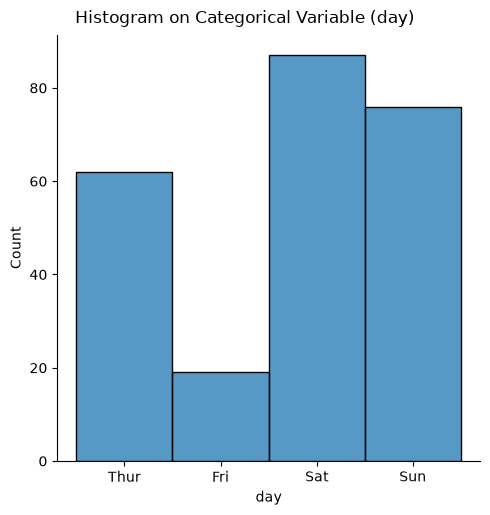

In [15]:
# Categorical variable Histogram
# Seaborn auto-uses discrete bins for categorical variables (acts like a Count Plot)
sns.displot(data=tips, x='day', kind='hist')
plt.suptitle('Histogram on Categorical Variable (day)', y=1.02)
plt.show()

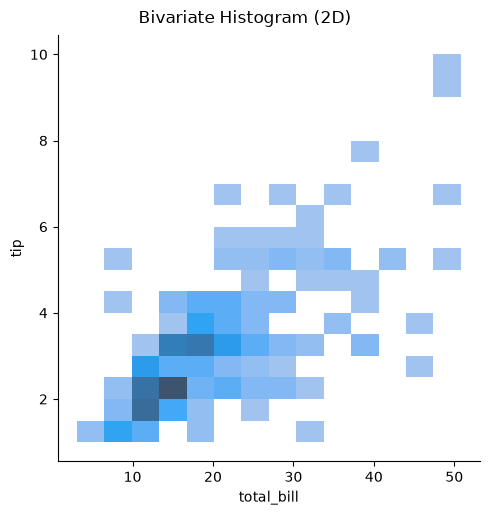

In [16]:
# Bivariate Histogram , two continuous variables
# Bins data in 2D rectangles, colors cells by count
sns.displot(data=tips, x='total_bill', y='tip', kind='hist')
plt.suptitle('Bivariate Histogram (2D)', y=1.02)
plt.show()

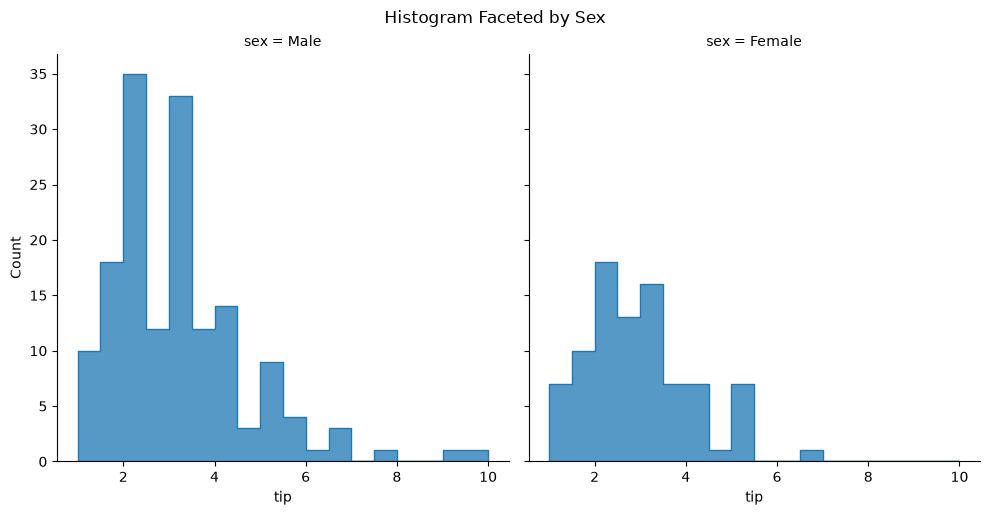

In [17]:
# Faceting , col= and row= only work with displot(), NOT histplot()
sns.displot(data=tips, x='tip', kind='hist', col='sex', element='step')
plt.suptitle('Histogram Faceted by Sex', y=1.02)
plt.show()

### **2.2 KDE Plot (Kernel Density Estimate)**

**What is it?** A **smooth continuous curve** estimating the **probability density** of the data.
Uses a Gaussian kernel to smooth , no discrete bins needed.

**Use it when:**
- You want a **smoother view** of the distribution than a histogram
- You want to **compare distributions** of multiple groups cleanly
- You need to show **probability density** (area under curve = 1)

**Histogram vs KDE:**
- Histogram shows counts; KDE shows density (normalized)
- KDE avoids the bin size sensitivity problem of histograms
- KDE gives a smoother, more continuous picture of the distribution

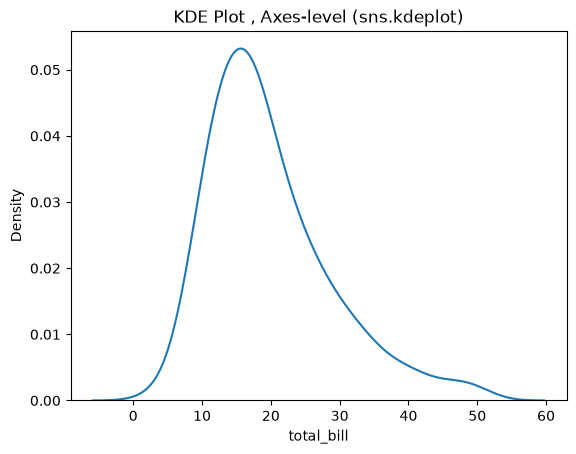

In [18]:
# AXES-LEVEL: sns.kdeplot()
sns.kdeplot(data=tips, x='total_bill')
plt.title('KDE Plot , Axes-level (sns.kdeplot)')
plt.show()

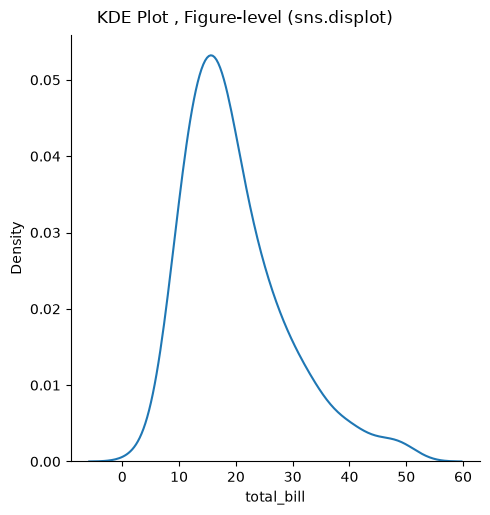

In [19]:
# FIGURE-LEVEL: sns.displot(kind="kde")
sns.displot(data=tips, x='total_bill', kind='kde')
plt.suptitle('KDE Plot , Figure-level (sns.displot)', y=1.02)
plt.show()

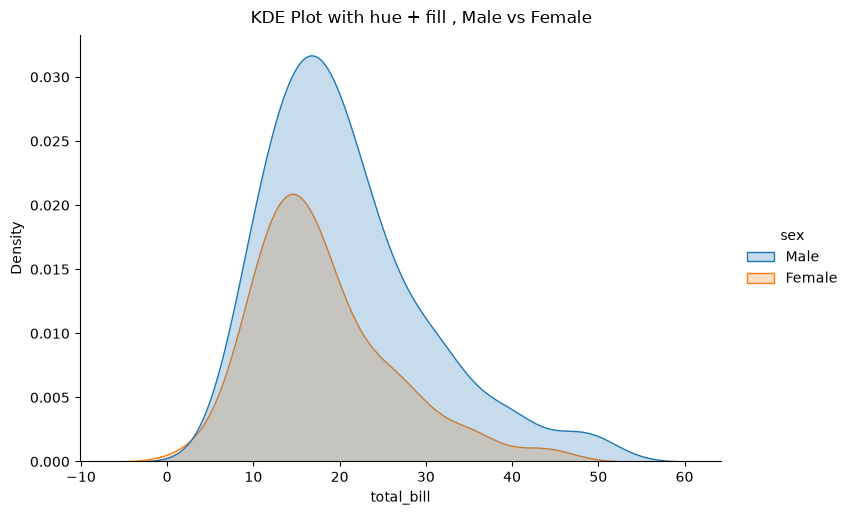

In [20]:
# KDE with hue and fill , compare groups with shaded areas
sns.displot(
    data=tips, x='total_bill', kind='kde',
    hue='sex', fill=True, height=5, aspect=1.5
)
plt.suptitle('KDE Plot with hue + fill , Male vs Female', y=1.02)
plt.show()

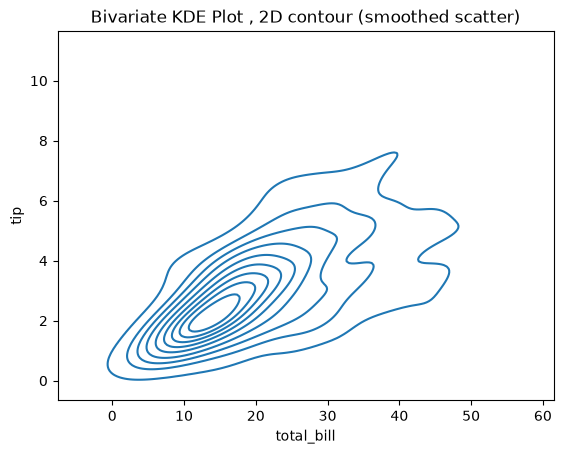

In [21]:
# Bivariate KDE Plot , two variables
# Contour lines show where most data is concentrated
sns.kdeplot(data=tips, x='total_bill', y='tip')
plt.title('Bivariate KDE Plot , 2D contour (smoothed scatter)')
plt.show()

### **2.3 Rug Plot**

**What is it?** Draws a **small vertical tick mark at each data point** along an axis.
Shows the **exact location of every individual observation** , no smoothing, no binning.

**Use it when:**
- You want to show **where individual data points actually are**
- You want to **complement a KDE or histogram** with raw data positions
- You want transparent view of **data density or gaps**

> **Tip:** Almost always used **together with** a KDE or histogram , rarely alone.

> **Note:** `sns.rugplot()` has no figure-level equivalent , always axes-level.

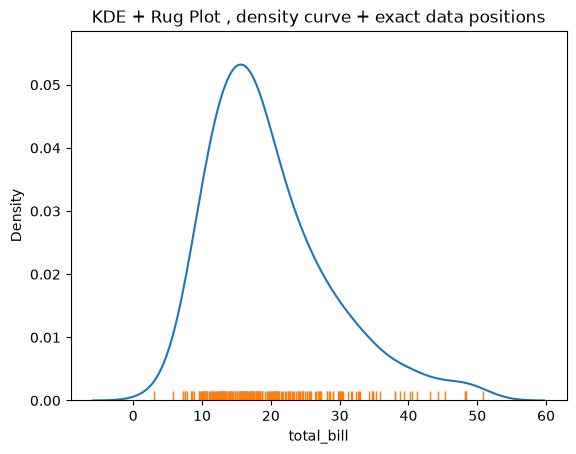

In [22]:
# AXES-LEVEL: sns.rugplot()
# Best used on top of another distribution plot
# Tick marks show exactly where each data point lies

sns.kdeplot(data=tips, x='total_bill')
sns.rugplot(data=tips, x='total_bill')
plt.title('KDE + Rug Plot , density curve + exact data positions')
plt.show()

---

## **3. Categorical Plots**

### What are Categorical Plots?
Used when **one (or more) variables is categorical** (labels like gender, day, species).

**Three sub-types based on what they show:**

| Sub-type | Purpose | Plots |
|----------|---------|-------|
| Categorical Scatter | Show individual data points per category | Strip Plot, Swarm Plot |
| Categorical Distribution | Show spread / distribution per category | Box Plot, Violin Plot |
| Categorical Estimate | Show a summary statistic per category | Bar Plot, Count Plot |

- **Figure-level function:** `sns.catplot(kind="bar"` / `"count"` / `"box"` / `"violin"` / `"swarm"` / `"strip")`
- **Axes-level functions:** `sns.barplot()` / `sns.countplot()` / `sns.boxplot()` / `sns.violinplot()` / `sns.swarmplot()` / `sns.stripplot()`

---

### **3.1 Bar Plot**

**What is it?** Shows the **estimated mean** of a numerical variable **for each category**,
with error bars showing confidence intervals.

**Use it when:**
- You want to **compare averages** across groups
- You want to see which category has the **highest or lowest mean**
- You want uncertainty shown via **confidence intervals**

> **WARNING:** A Bar Plot shows the **MEAN** by default , not a count.
> For counting items per group, use **Count Plot** instead.

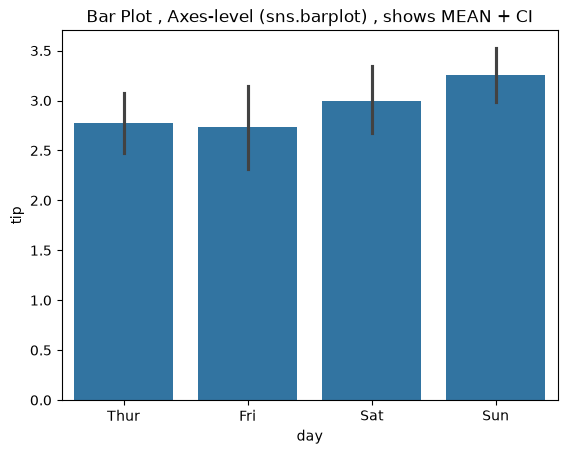

In [23]:
# AXES-LEVEL: sns.barplot()
# Shows mean tip for each day with 95% CI error bars
sns.barplot(data=tips, x='day', y='tip')
plt.title('Bar Plot , Axes-level (sns.barplot) , shows MEAN + CI')
plt.show()

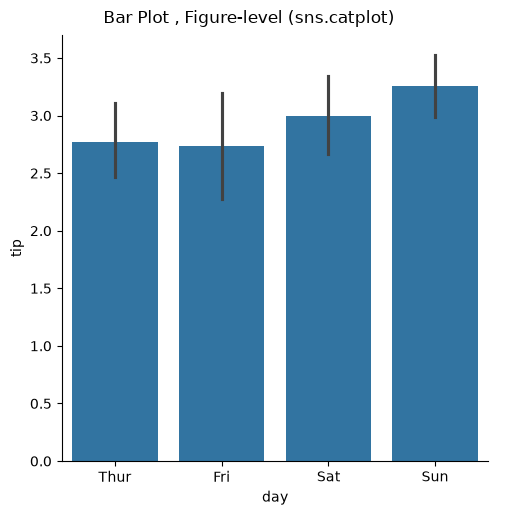

In [24]:
# FIGURE-LEVEL: sns.catplot(kind="bar")
sns.catplot(data=tips, x='day', y='tip', kind='bar')
plt.suptitle('Bar Plot , Figure-level (sns.catplot)', y=1.02)
plt.show()

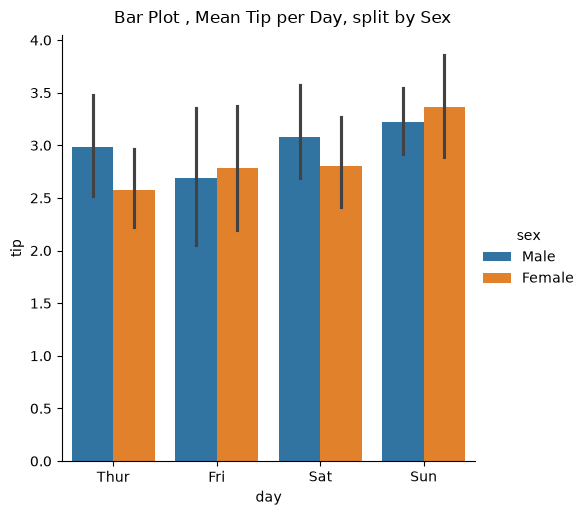

In [25]:
# hue , compare sub-groups within each bar
sns.catplot(data=tips, x='day', y='tip', kind='bar', hue='sex')
plt.suptitle('Bar Plot , Mean Tip per Day, split by Sex', y=1.02)
plt.show()

### **3.2 Count Plot**

**What is it?** Counts the **number of observations** in each category and shows bars.
Essentially a **histogram for categorical data**.

**Use it when:**
- You want to know **how many rows** belong to each category
- You want to check for **class imbalance** in your dataset
- You want to see the **frequency distribution** of a categorical column

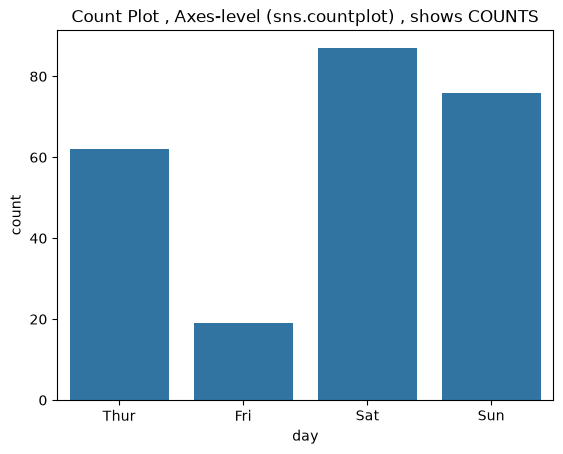

In [26]:
# AXES-LEVEL: sns.countplot()
sns.countplot(data=tips, x='day')
plt.title('Count Plot , Axes-level (sns.countplot) , shows COUNTS')
plt.show()

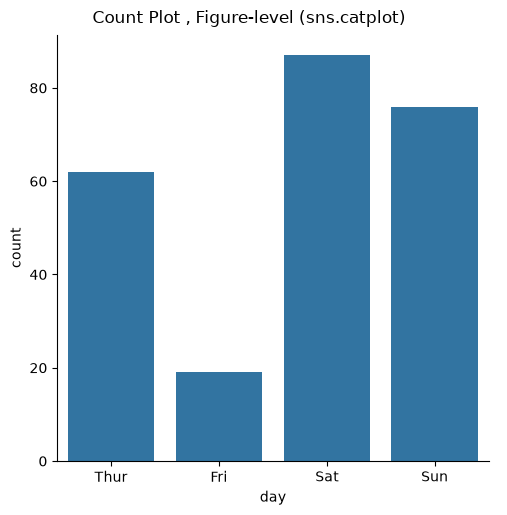

In [27]:
# FIGURE-LEVEL: sns.catplot(kind="count")
sns.catplot(data=tips, x='day', kind='count')
plt.suptitle('Count Plot , Figure-level (sns.catplot)', y=1.02)
plt.show()

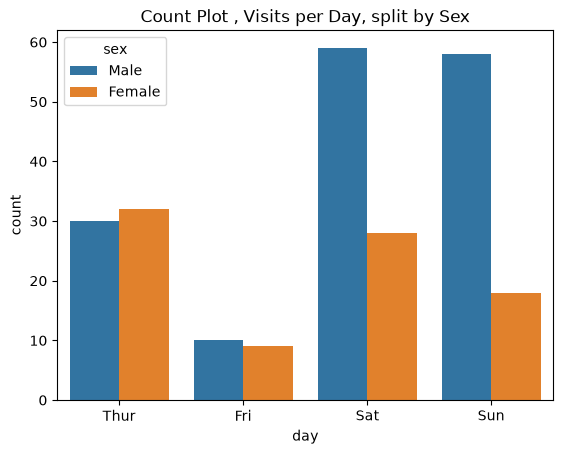

In [28]:
# hue , break down counts by a second category
sns.countplot(data=tips, x='day', hue='sex')
plt.title('Count Plot , Visits per Day, split by Sex')
plt.show()

### **3.3 Box Plot**

**What is it?** Summarizes a distribution using **5 key statistics**:
- **Box:** Q1 (25th percentile) to Q3 (75th percentile) , the middle 50% of data (IQR)
- **Line inside box:** Median (50th percentile)
- **Whiskers:** Most extreme non-outlier points (usually 1.5 x IQR from box edges)
- **Dots beyond whiskers:** Outliers

**Use it when:**
- You want to **compare distributions** across multiple categories
- You want to **identify outliers** easily
- You want to see if data is **symmetric or skewed**
- You want to compare **spread (IQR)** between groups

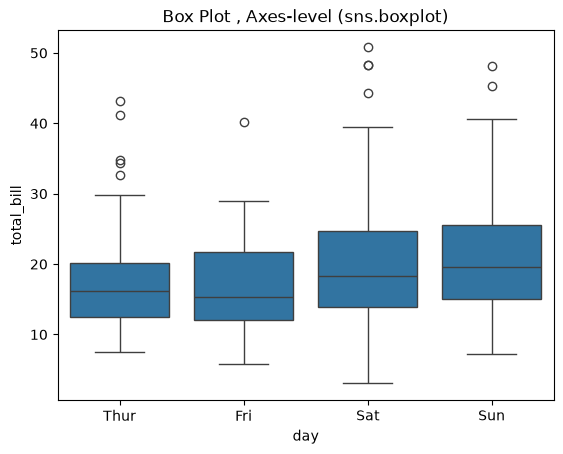

In [29]:
# AXES-LEVEL: sns.boxplot()
sns.boxplot(data=tips, x='day', y='total_bill')
plt.title('Box Plot , Axes-level (sns.boxplot)')
plt.show()

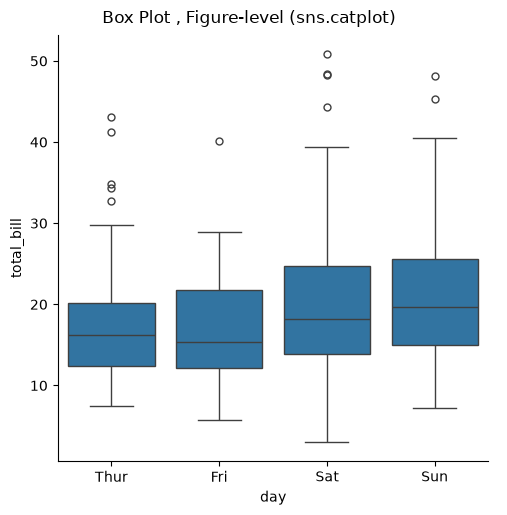

In [30]:
# FIGURE-LEVEL: sns.catplot(kind="box")
sns.catplot(data=tips, x='day', y='total_bill', kind='box')
plt.suptitle('Box Plot , Figure-level (sns.catplot)', y=1.02)
plt.show()

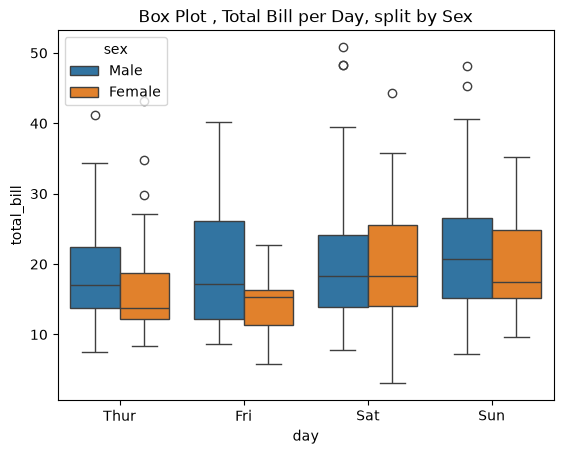

In [31]:
# hue , add sub-group coloring
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex')
plt.title('Box Plot , Total Bill per Day, split by Sex')
plt.show()

### **3.4 Violin Plot**

**What is it?** Combines a **Box Plot** and a **KDE Plot**:
- **Full distribution shape** from KDE (wider = more data there, narrower = fewer points)
- **Median and IQR** from the inner box plot

**Use it when:**
- You want **more detail than a Box Plot** , see the actual distribution shape
- You want to spot **bimodal distributions** (two humps) , box plots hide this!
- You want to compare **full distributions** between groups

**Box Plot vs Violin Plot:**
- Box Plot: compact, good for outliers, but hides distribution shape
- Violin Plot: shows full shape , reveals skewness and multiple modes

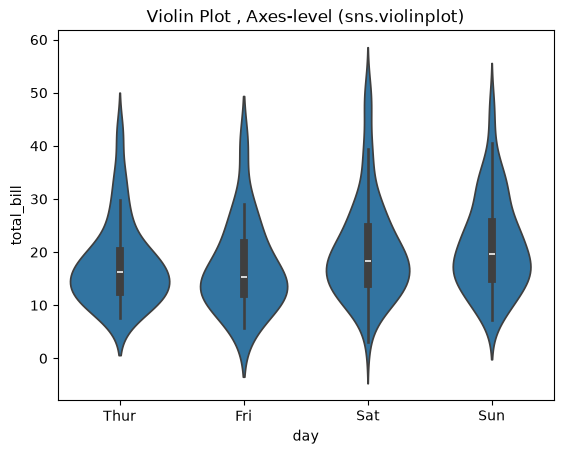

In [32]:
# AXES-LEVEL: sns.violinplot()
sns.violinplot(data=tips, x='day', y='total_bill')
plt.title('Violin Plot , Axes-level (sns.violinplot)')
plt.show()

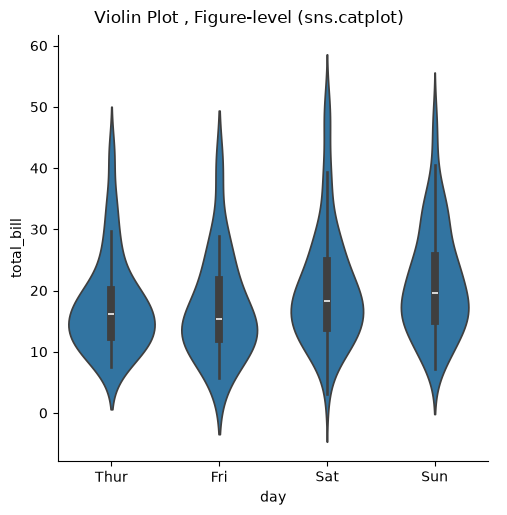

In [33]:
# FIGURE-LEVEL: sns.catplot(kind="violin")
sns.catplot(data=tips, x='day', y='total_bill', kind='violin')
plt.suptitle('Violin Plot , Figure-level (sns.catplot)', y=1.02)
plt.show()

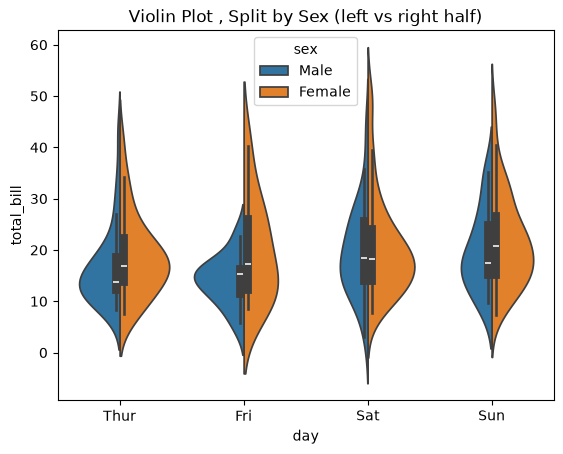

In [34]:
# hue + split: two groups side-by-side within one violin
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex', split=True)
plt.title('Violin Plot , Split by Sex (left vs right half)')
plt.show()

### **3.5 Swarm Plot**

**What is it?** Displays **every individual data point** as a dot,
arranged so dots **do not overlap**. Points spread out to show density.

**Use it when:**
- Your dataset is **small enough** to show individual points without crowding
- You want to see **every single observation** and its exact value
- You want **full data transparency** in your visualization

> **Warning:** For very large datasets, Swarm Plot becomes slow and crowded.
> Use Violin or Box Plot for large data instead.

**Strip Plot vs Swarm Plot:**
- Strip Plot: points may overlap (random jitter reduces overlap)
- Swarm Plot: points **never overlap** , algorithm adjusts each point's x-position

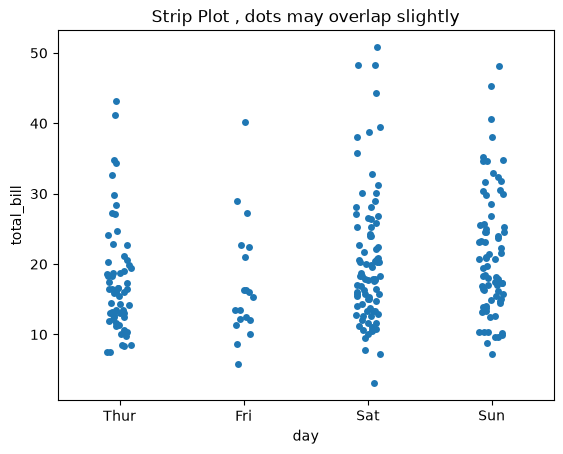

In [35]:
# AXES-LEVEL: Strip Plot (cousin of Swarm Plot, allows slight overlap)
sns.stripplot(data=tips, x='day', y='total_bill')
plt.title('Strip Plot , dots may overlap slightly')
plt.show()

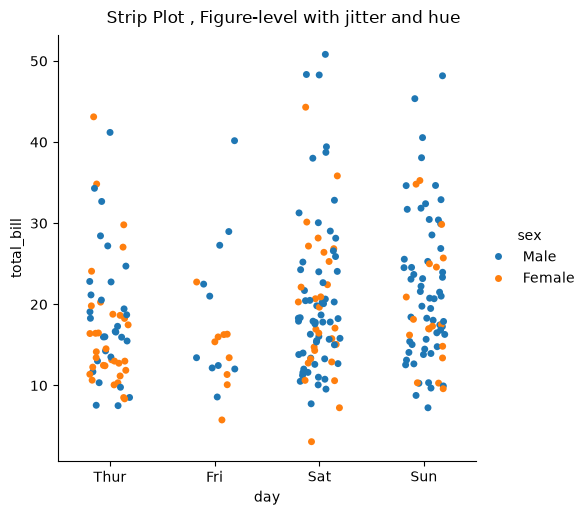

In [36]:
# FIGURE-LEVEL: Strip Plot via catplot with jitter and hue
sns.catplot(data=tips, x='day', y='total_bill', kind='strip', jitter=0.2, hue='sex')
plt.suptitle('Strip Plot , Figure-level with jitter and hue', y=1.02)
plt.show()

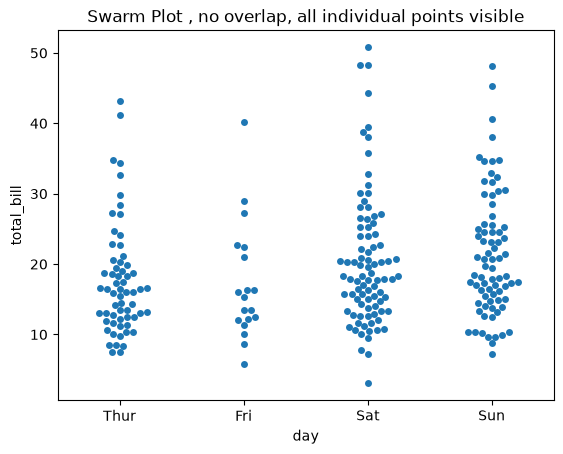

In [37]:
# AXES-LEVEL: Swarm Plot
# Dots are adjusted so they NEVER overlap
sns.swarmplot(data=tips, x='day', y='total_bill')
plt.title('Swarm Plot , no overlap, all individual points visible')
plt.show()

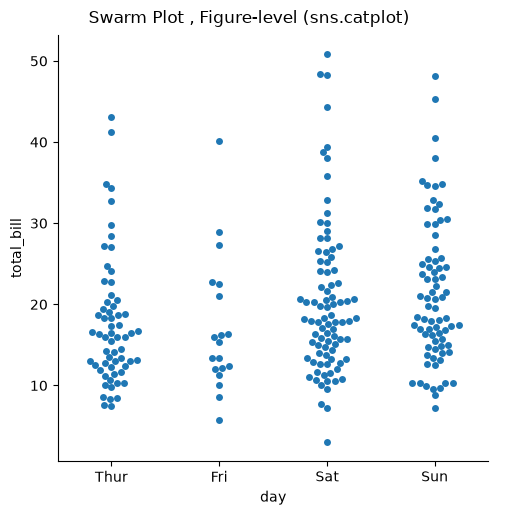

In [38]:
# FIGURE-LEVEL: Swarm Plot via catplot
sns.catplot(data=tips, x='day', y='total_bill', kind='swarm')
plt.suptitle('Swarm Plot , Figure-level (sns.catplot)', y=1.02)
plt.show()

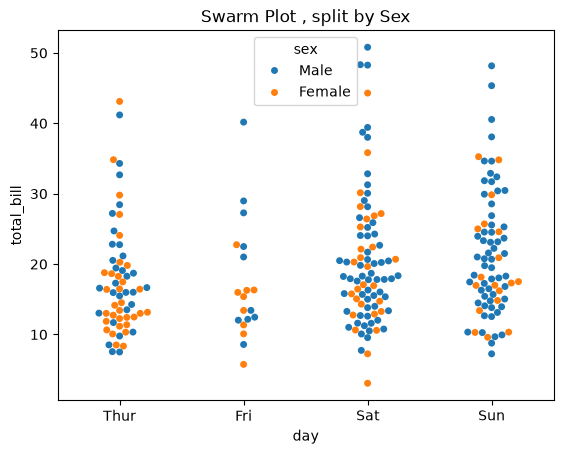

In [39]:
# Swarm Plot with hue
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex')
plt.title('Swarm Plot , split by Sex')
plt.show()

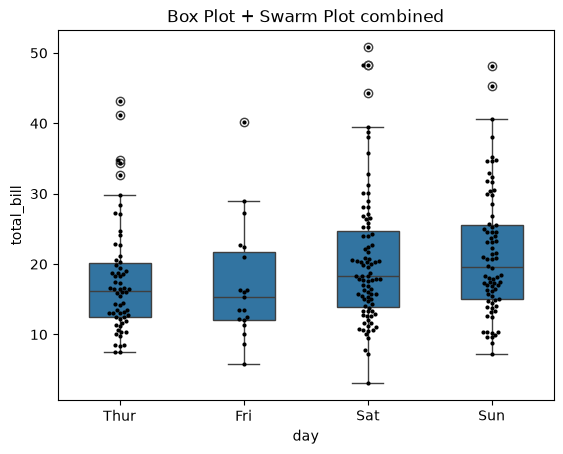

In [40]:
# PRO TIP: Overlay Swarm Plot on Box Plot
# Best of both worlds , distribution summary + all raw data points
ax = sns.boxplot(data=tips, x='day', y='total_bill', width=0.5)
sns.swarmplot(data=tips, x='day', y='total_bill', color='k', size=3, ax=ax)
plt.title('Box Plot + Swarm Plot combined')
plt.show()

---

## **4. Matrix Plots**

### What are Matrix Plots?
Designed to visualize **2D tabular (matrix) data** , data with meaningful values at every cell of a grid (rows x columns).

**Common use-cases:**
- Correlation matrices (how features relate to each other)
- Cross-tabulations (value by two categories)
- Time series by category (e.g., country x year)

**Plots in this category:** Heatmap, Clustermap

**Note on function levels:**
- `sns.heatmap()` is **Axes-level** only (no figure-level equivalent)
- `sns.clustermap()` is **Figure-level** only (creates its own figure with dendrograms)

---

### **4.1 Heatmap**

**What is it?** Represents a **matrix of values as colors**.
Each cell is colored based on its value , darker/brighter = higher values.

**Use it when:**
- Visualizing a **correlation matrix** (which features are related)
- Showing **pivot table data** (e.g., sales by region x month)
- Comparing values across **two categorical dimensions**
- Displaying any **2D numerical grid**

**Key parameters:**
- `annot=True` , show the actual number in each cell
- `cmap=` , color palette (`"coolwarm"`, `"summer"`, `"Blues"`, etc.)
- `linewidth=` , spacing between cells

> **Note:** `sns.heatmap()` is an Axes-level function only.

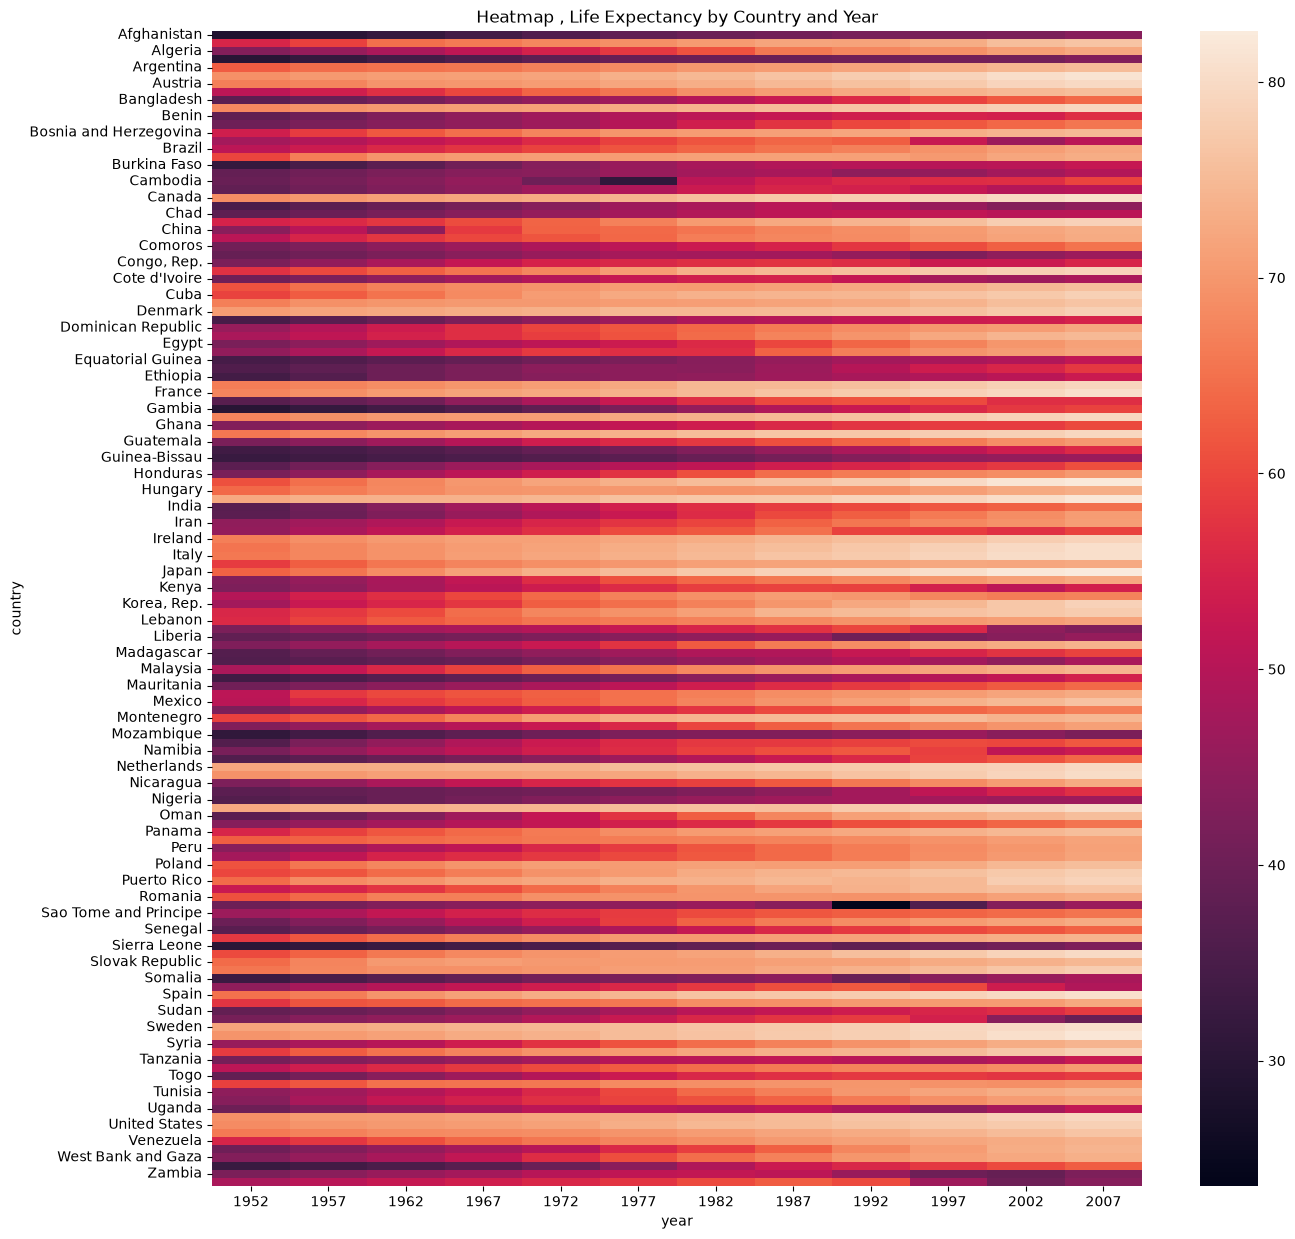

In [41]:
# Prepare pivot table: countries x years with life expectancy values
pivot_all = gap.pivot(index='country', columns='year', values='lifeExp')

# AXES-LEVEL: sns.heatmap() , only option for heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(pivot_all)
plt.title('Heatmap , Life Expectancy by Country and Year')
plt.show()

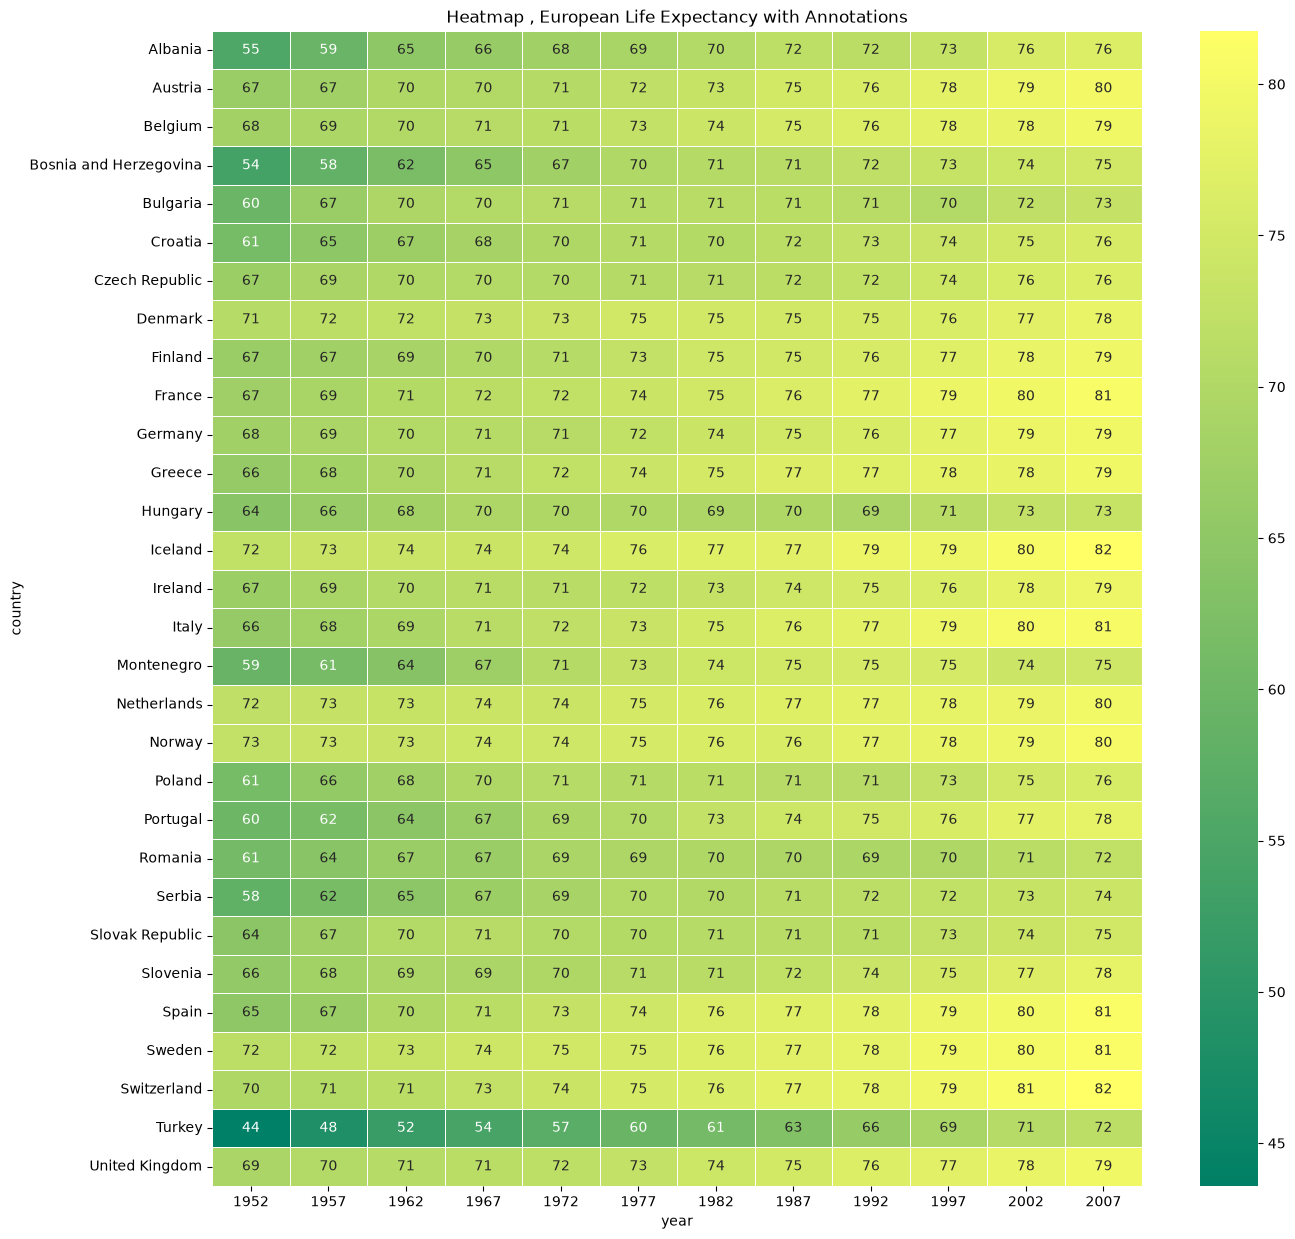

In [42]:
# Heatmap with annotations , numbers visible in cells
pivot_europe = gap[gap['continent'] == 'Europe'].pivot(
    index='country', columns='year', values='lifeExp'
)

plt.figure(figsize=(15, 15))
sns.heatmap(pivot_europe, annot=True, linewidth=0.5, cmap='summer')
plt.title('Heatmap , European Life Expectancy with Annotations')
plt.show()

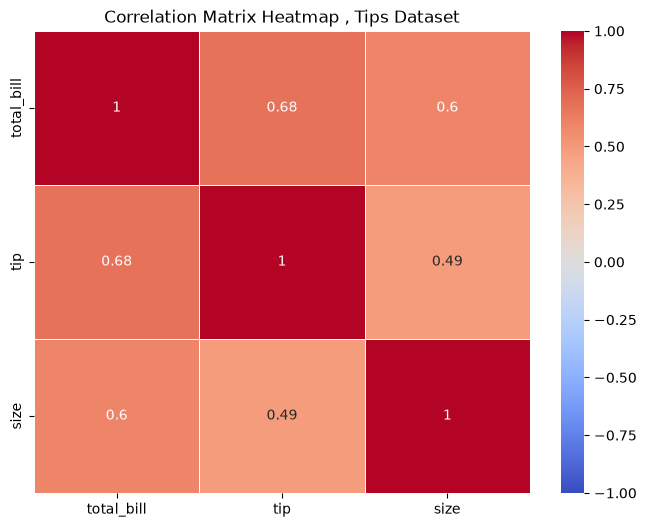

In [43]:
# Most common use: Correlation Matrix Heatmap
# Shows which numerical features are correlated with each other
corr = tips.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidth=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap , Tips Dataset')
plt.show()

### **4.2 Clustermap**

**What is it?** A **Heatmap with hierarchical clustering** applied to both rows and columns.
Reorders rows and columns so **similar ones are grouped together**,
and adds **dendrograms** (tree diagrams) showing the clustering structure.

**Use it when:**
- You want to find **natural groupings** in your data automatically
- You want to see which **features (columns) are related** to each other
- You want to find **clusters of observations (rows)** that behave similarly
- Exploratory analysis of high-dimensional datasets

**Heatmap vs Clustermap:**
- Heatmap: keeps the **original** row/column order
- Clustermap: **reorders** rows and columns to reveal hidden clusters + adds dendrograms

> **Note:** `sns.clustermap()` is Figure-level. Requires scipy (`pip install scipy`).

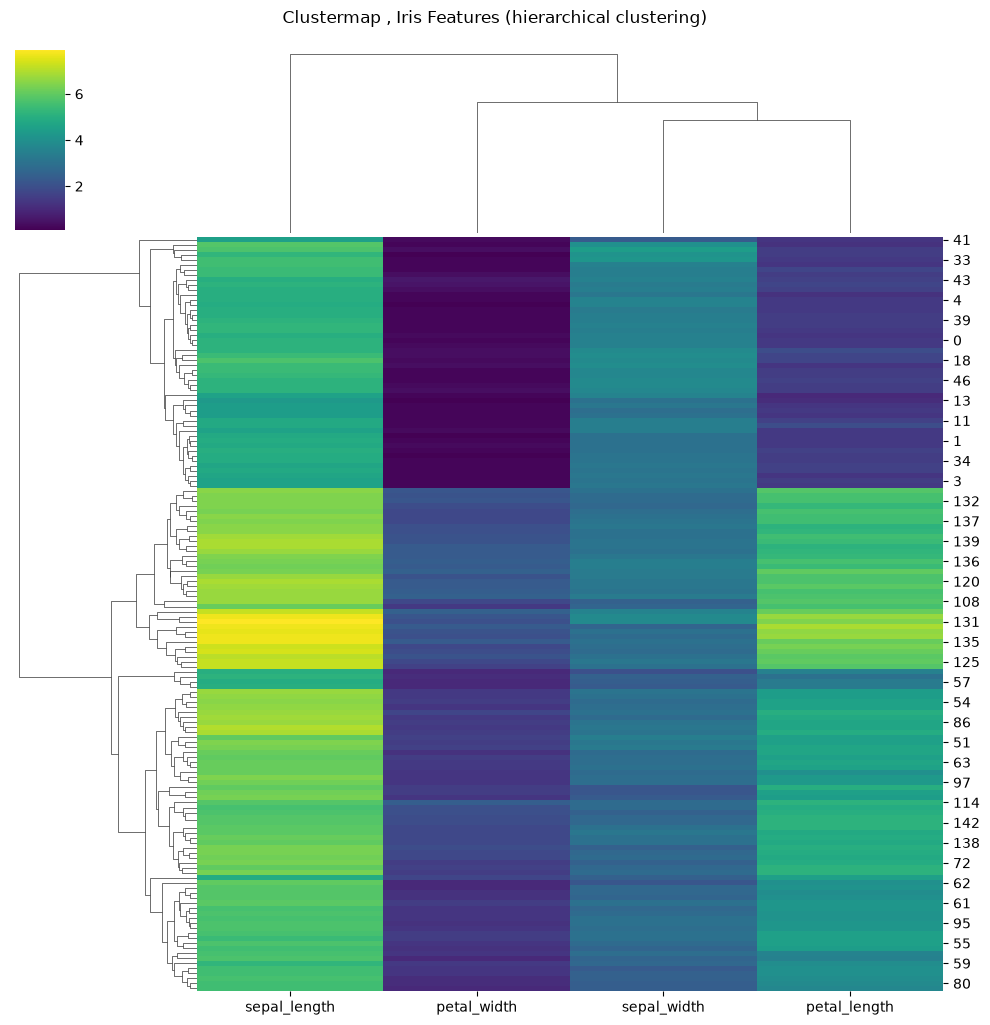

In [44]:
# FIGURE-LEVEL: sns.clustermap() , creates its own figure with dendrograms
# Iris dataset: 4 numerical features
# Clustermap groups similar flowers (rows) and similar features (columns)

sns.clustermap(
    iris.iloc[:, :4],
    cmap='viridis',
    figsize=(10, 10)
)
plt.suptitle('Clustermap , Iris Features (hierarchical clustering)', y=1.02)
plt.show()

---

## **5. Regression Plots**

### What are Regression Plots?
Visualize the **relationship between two continuous variables** and overlay a
**fitted regression line** with a confidence band to show the trend.

**Use it when:**
- You want to see if a **linear relationship** exists between two variables
- You want to visualize **how well a line fits** your data
- You want to **explore potential predictors** before building a model

**Plots in this category:**
- `sns.regplot()` , **Axes-level:** scatter + linear regression line
- `sns.lmplot()` , **Figure-level:** same but supports `col=` and `row=` for faceting

---

### **5.1 Regression Plot (regplot / lmplot)**

**What is it?** Draws a **scatter plot** with a **linear regression line**
and a **shaded confidence band** (95% by default).

**Use it when:**
- You want to check if two variables have a **linear relationship**
- You want to visualize the **trend and uncertainty** of a regression
- You are doing **exploratory data analysis (EDA)** before modeling

**Key parameters:**
- `ci=` , confidence interval width (default 95; set to `None` to hide band)
- `order=` , polynomial degree (e.g., `order=2` for quadratic curve)
- `logistic=True` , fit a logistic regression (for binary y variable)

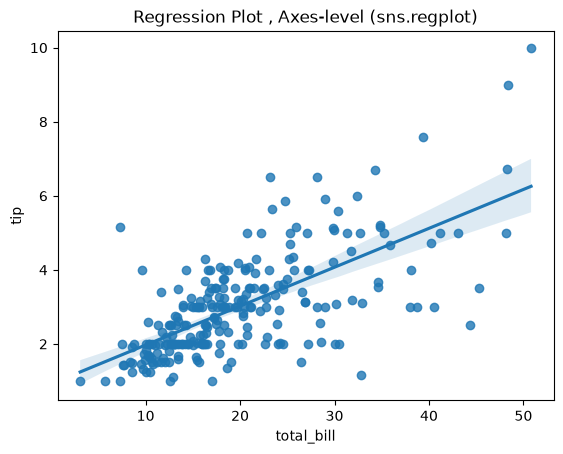

In [45]:
# AXES-LEVEL: sns.regplot()
# Scatter + linear regression line + 95% confidence band
sns.regplot(data=tips, x='total_bill', y='tip')
plt.title('Regression Plot , Axes-level (sns.regplot)')
plt.show()

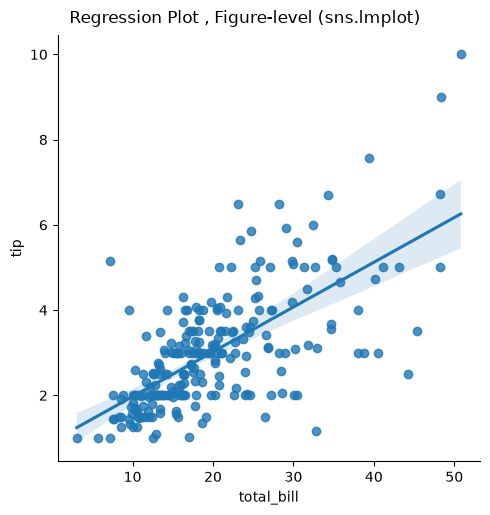

In [46]:
# FIGURE-LEVEL: sns.lmplot()
# Same as regplot but supports col= and row= for faceting
sns.lmplot(data=tips, x='total_bill', y='tip')
plt.suptitle('Regression Plot , Figure-level (sns.lmplot)', y=1.02)
plt.show()

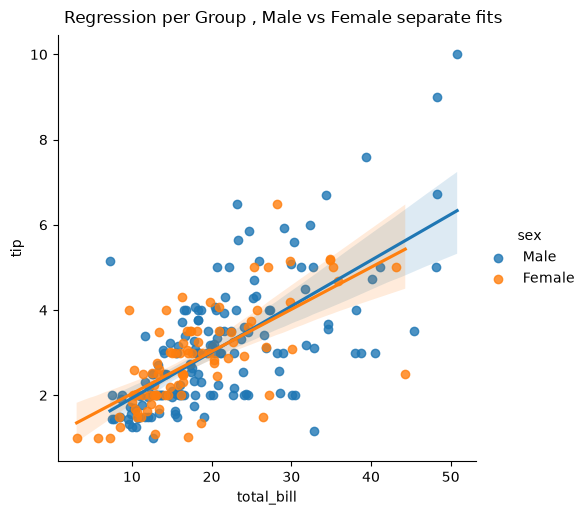

In [47]:
# Regression by group using hue , separate fit per group
sns.lmplot(data=tips, x='total_bill', y='tip', hue='sex')
plt.suptitle('Regression per Group , Male vs Female separate fits', y=1.02)
plt.show()

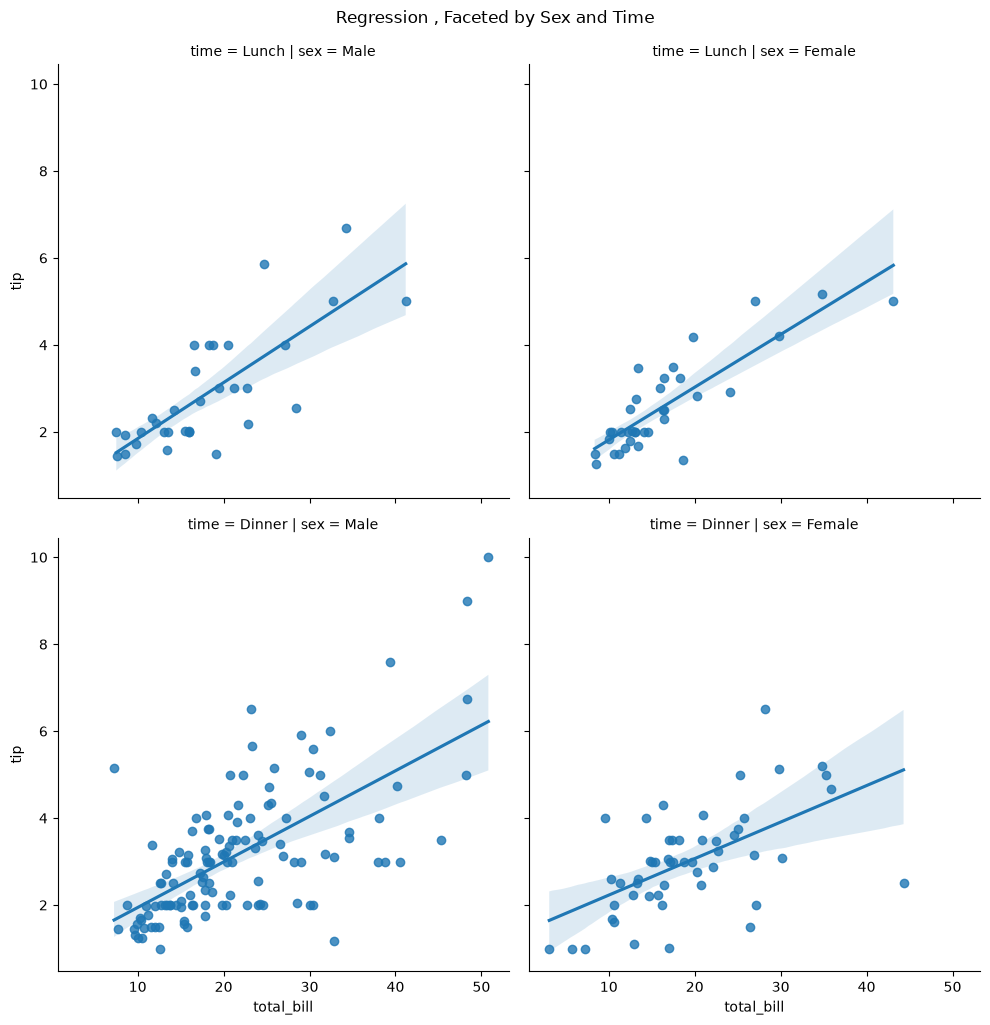

In [48]:
# Faceted Regression , col= and row= only possible with lmplot
sns.lmplot(data=tips, x='total_bill', y='tip', col='sex', row='time')
plt.suptitle('Regression , Faceted by Sex and Time', y=1.02)
plt.show()

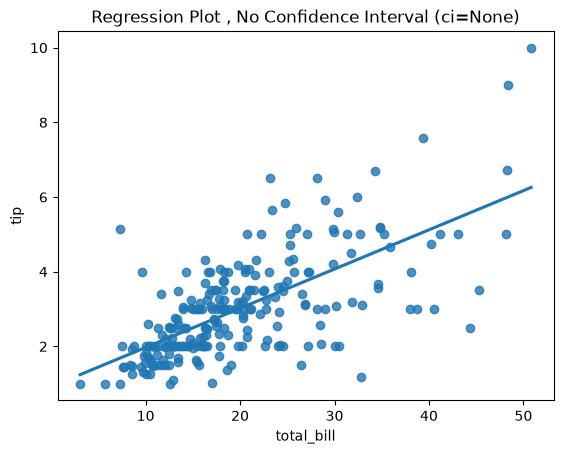

In [49]:
# ci=None , hide the confidence interval band
sns.regplot(data=tips, x='total_bill', y='tip', ci=None)
plt.title('Regression Plot , No Confidence Interval (ci=None)')
plt.show()

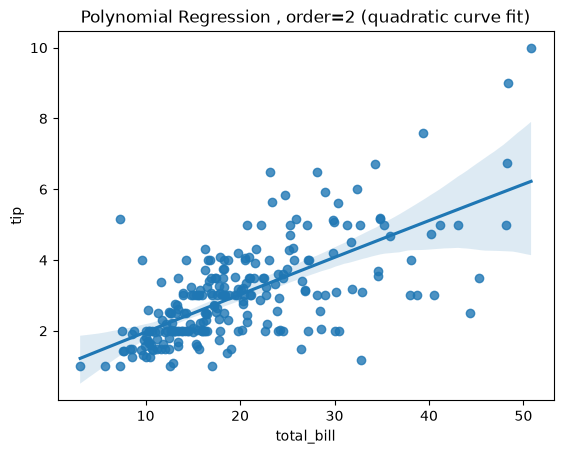

In [50]:
# order=2 , Polynomial (quadratic) regression
# Use when the relationship is curved, not straight
sns.regplot(data=tips, x='total_bill', y='tip', order=2)
plt.title('Polynomial Regression , order=2 (quadratic curve fit)')
plt.show()

---

## **Summary , Quick Reference Table**

| Category | Plot | Axes-level Function | Figure-level Function | Best Used When |
|----------|------|--------------------|-----------------------|----------------|
| Relational | Scatter Plot | `sns.scatterplot()` | `sns.relplot(kind="scatter")` | Relationship between 2 continuous variables |
| Relational | Line Plot | `sns.lineplot()` | `sns.relplot(kind="line")` | Trends over time or ordered sequences |
| Distribution | Histogram | `sns.histplot()` | `sns.displot(kind="hist")` | Frequency / shape of a single variable |
| Distribution | KDE Plot | `sns.kdeplot()` | `sns.displot(kind="kde")` | Smooth density curve of a variable |
| Distribution | Rug Plot | `sns.rugplot()` | axes-level only | Mark exact individual data positions |
| Categorical | Bar Plot | `sns.barplot()` | `sns.catplot(kind="bar")` | Compare means across categories |
| Categorical | Count Plot | `sns.countplot()` | `sns.catplot(kind="count")` | Count of items per category |
| Categorical | Box Plot | `sns.boxplot()` | `sns.catplot(kind="box")` | Distribution summary + outliers |
| Categorical | Violin Plot | `sns.violinplot()` | `sns.catplot(kind="violin")` | Full distribution shape per category |
| Categorical | Swarm Plot | `sns.swarmplot()` | `sns.catplot(kind="swarm")` | Every individual point without overlap |
| Matrix | Heatmap | `sns.heatmap()` | axes-level only | Color-coded matrix / correlation table |
| Matrix | Clustermap | figure-level only | `sns.clustermap()` | Clustered heatmap with dendrograms |
| Regression | Regression Plot | `sns.regplot()` | `sns.lmplot()` | Linear fit between two variables |

---

## **Key Takeaways**

**1. Figure-level vs Axes-level** , most important distinction:
- **Axes-level:** simple, quick, works inside your own matplotlib figure
- **Figure-level:** managed layout, enables faceting with `col=` / `row=`

**2. Pick your plot by data type:**
- Two continuous variables → Scatter / Line / Regression
- One continuous variable → Histogram / KDE / Rug
- One continuous + One categorical → Box / Violin / Bar / Swarm
- Pure categorical (counts) → Count Plot
- Grid of numbers → Heatmap / Clustermap

**3. Enhance any plot with semantic parameters:**
- `hue=` , color by a third categorical variable
- `style=` , marker style by a variable (relational plots)
- `size=` , marker or line size by a variable
- `col=` / `row=` , facet into multiple subplots (**Figure-level only!**)

**4. Choosing between Box, Violin, and Swarm:**
- **Box Plot** , compact summary, great for spotting outliers
- **Violin Plot** , richer view, reveals full distribution shape
- **Swarm Plot** , maximum transparency, shows every individual point
- **Box + Swarm overlay** , the complete picture!